In [2]:
import pandas as pd
df = pd.read_csv('data/student-por.csv', sep=',')
print(df.shape)
df.head()

(649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
df.info()
print(df.isnull().sum())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


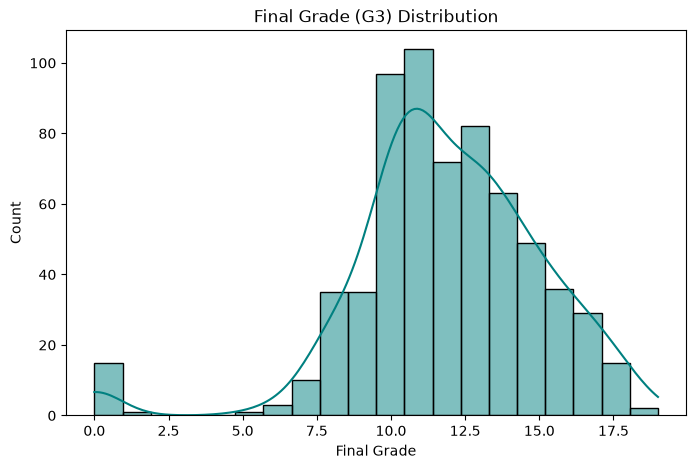

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=20, kde=True, color='teal')
plt.title('Final Grade (G3) Distribution')
plt.xlabel('Final Grade')
plt.savefig('grade_distribution.png')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_11748\474760527.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='studytime', y='G3', data=df, palette='viridis')


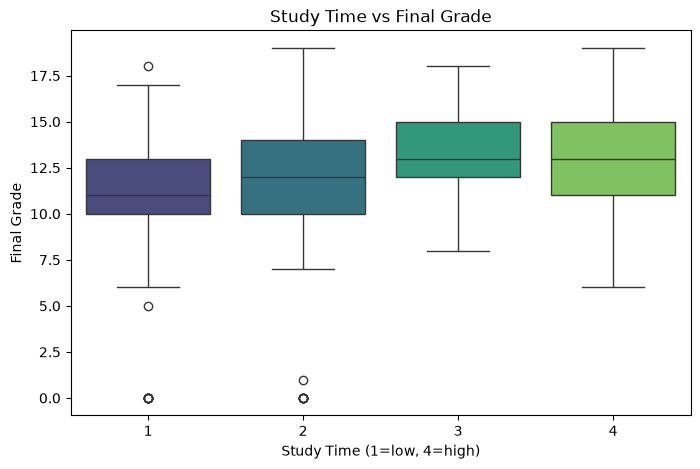

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(x='studytime', y='G3', data=df, palette='viridis')
plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time (1=low, 4=high)')
plt.ylabel('Final Grade')
plt.savefig('studytime_vs_grade.png')
plt.show()

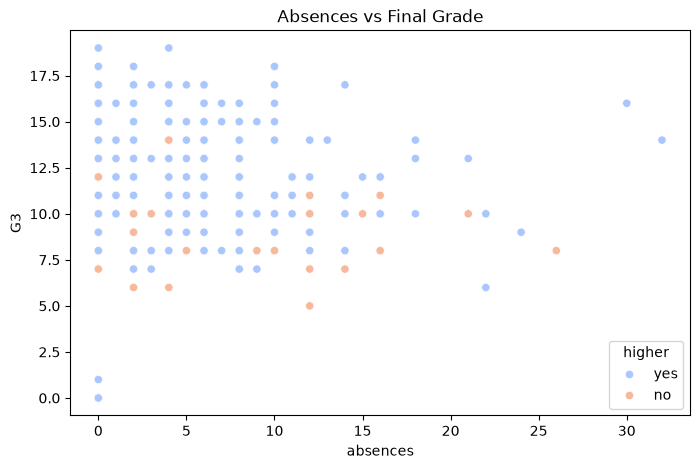

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='absences', y='G3', data=df, hue='higher', palette='coolwarm')
plt.title('Absences vs Final Grade')
plt.savefig('absences_vs_grade.png')
plt.show()

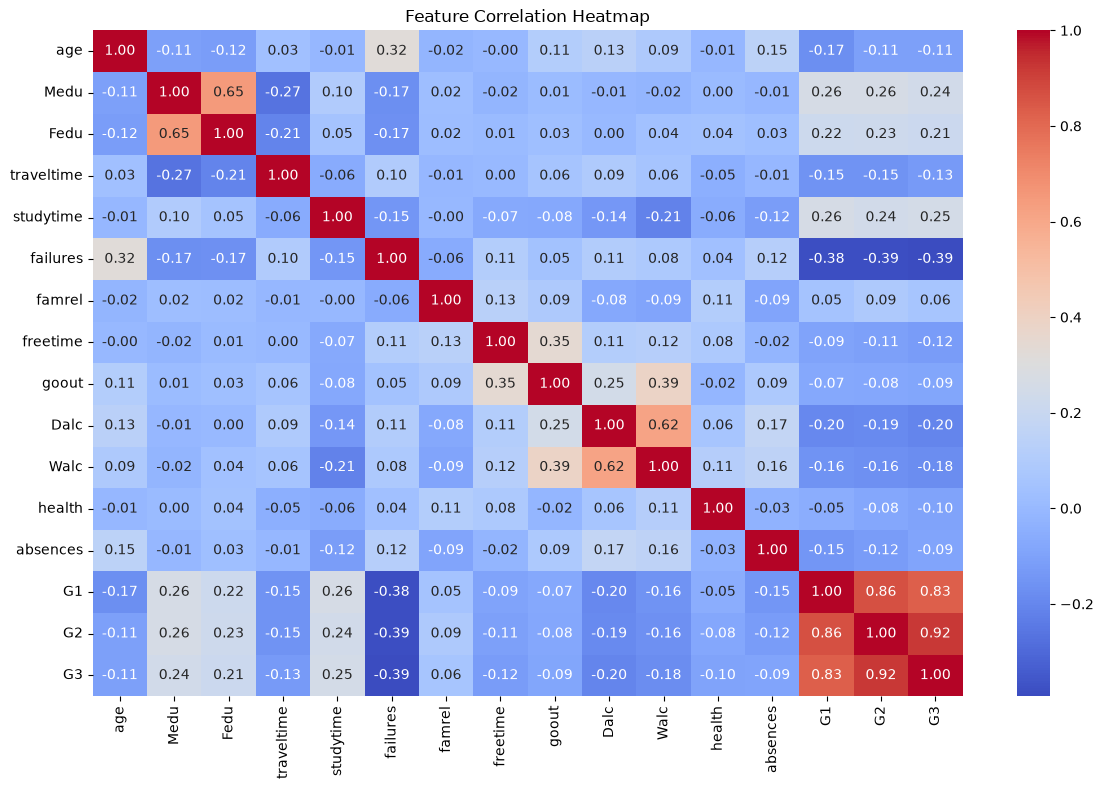

In [7]:
import numpy as np

plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [8]:
def get_risk_level(grade):
    if grade < 10:
        return 'High'
    elif grade < 14:
        return 'Medium'
    else:
        return 'Low'

df['risk_level'] = df['G3'].apply(get_risk_level)
print(df['risk_level'].value_counts())

risk_level
Medium    355
Low       194
High      100
Name: count, dtype: int64


In [9]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('risk_level')

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

print("Encoded columns:", categorical_cols)
df_model.head()

Encoded columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


C:\Users\HP\AppData\Local\Temp\ipykernel_11748\1107961945.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,risk_level
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,4,0,11,11,Medium
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,2,9,11,11,Medium
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,6,12,13,12,Medium
3,0,0,15,1,0,1,4,2,1,3,...,2,2,1,1,5,0,14,14,14,Low
4,0,0,16,1,0,1,3,3,2,2,...,3,2,1,2,5,0,11,13,13,Medium


In [10]:
feature_cols = [c for c in df_model.columns if c not in ['G1', 'G2', 'G3', 'risk_level']]
X = df_model[feature_cols]
y_score = df_model['G3']
y_risk = df_model['risk_level']

print("Features used:", feature_cols)
print("Total features:", len(feature_cols))


Features used: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Total features: 30


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_score_train, y_score_test = train_test_split(
    X, y_score, test_size=0.2, random_state=42
)
_, _, y_risk_train, y_risk_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (519, 30)
Test size: (130, 30)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

reg_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train, y_score_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_score_test, preds)
    r2 = r2_score(y_score_test, preds)
    reg_results[name] = {'MAE': mae, 'R2': r2, 'model': model}
    print(f"{name} -> MAE: {mae:.2f}, R2: {r2:.2f}")

Linear Regression -> MAE: 2.11, R2: 0.17
Random Forest -> MAE: 2.08, R2: 0.16
XGBoost -> MAE: 2.12, R2: 0.13


In [13]:
best_reg_name = max(reg_results, key=lambda k: reg_results[k]['R2'])
best_reg_model = reg_results[best_reg_name]['model']
print("Best Regression Model:", best_reg_name)

Best Regression Model: Linear Regression


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# XGBoost needs numeric labels
risk_encoder = LabelEncoder()
y_risk_train_enc = risk_encoder.fit_transform(y_risk_train)
y_risk_test_enc = risk_encoder.transform(y_risk_test)

clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
}

clf_results = {}
for name, model in clf_models.items():
    model.fit(X_train, y_risk_train_enc)
    preds = model.predict(X_test)
    acc = accuracy_score(y_risk_test_enc, preds)
    clf_results[name] = {'Accuracy': acc, 'model': model}
    print(f"{name} -> Accuracy: {acc:.2f}")

Logistic Regression -> Accuracy: 0.62
Random Forest -> Accuracy: 0.59
XGBoost -> Accuracy: 0.67


In [15]:
best_clf_name = max(clf_results, key=lambda k: clf_results[k]['Accuracy'])
best_clf_model = clf_results[best_clf_name]['model']
print("Best Classification Model:", best_clf_name)

Best Classification Model: XGBoost


In [16]:
import joblib
import os

os.makedirs('saved_models', exist_ok=True)

joblib.dump(best_reg_model, 'saved_models/score_model.pkl')
joblib.dump(best_clf_model, 'saved_models/risk_model.pkl')
joblib.dump(encoders, 'saved_models/feature_encoders.pkl')
joblib.dump(risk_encoder, 'saved_models/risk_label_encoder.pkl')
joblib.dump(feature_cols, 'saved_models/feature_columns.pkl')

print("All models saved successfully!")
print("Best Regression Model:", best_reg_name)
print("Best Classification Model:", best_clf_name)

All models saved successfully!
Best Regression Model: Linear Regression
Best Classification Model: XGBoost
